In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [5]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [7]:
df.shape

(1200, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [9]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [10]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [11]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [15]:
df.shape

(1200, 14)

In [16]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [17]:
df.select_dtypes(include=np.number)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,5,570.62,7,2853.10
1,2,151.35,3,302.70
2,5,550.68,8,2753.40
3,1,273.19,5,273.19
4,4,626.01,8,2504.04
...,...,...,...,...
1195,1,107.04,6,107.04
1196,2,662.53,5,1325.06
1197,2,436.84,2,873.68
1198,4,262.52,4,1050.08


In [45]:
df.select_dtypes(include=["object", "string"])

""
0
1
2
3
4
...
1195
1196
1197
1198


In [19]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [20]:

df["CouponCode"] = df["CouponCode"].fillna("Unknown")

In [21]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

In [23]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [24]:
df.drop("Date", axis=1, inplace=True)

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns.union(
    df.select_dtypes(include="string").columns
):
    df[col] = le.fit_transform(df[col].astype(str))

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   int64  
 1   CustomerID       1200 non-null   int64  
 2   Product          1200 non-null   int64  
 3   Quantity         1200 non-null   int64  
 4   UnitPrice        1200 non-null   float64
 5   ShippingAddress  1200 non-null   int64  
 6   PaymentMethod    1200 non-null   int64  
 7   OrderStatus      1200 non-null   int64  
 8   TrackingNumber   1200 non-null   int64  
 9   ItemsInCart      1200 non-null   int64  
 10  CouponCode       1200 non-null   int64  
 11  ReferralSource   1200 non-null   int64  
 12  TotalPrice       1200 non-null   float64
 13  Year             1200 non-null   int32  
 14  Month            1200 non-null   int32  
 15  Day              1200 non-null   int32  
dtypes: float64(2), int32(3), int64(11)
memory usage: 136.1 KB


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [31]:
pca_data.shape

(1200, 2)

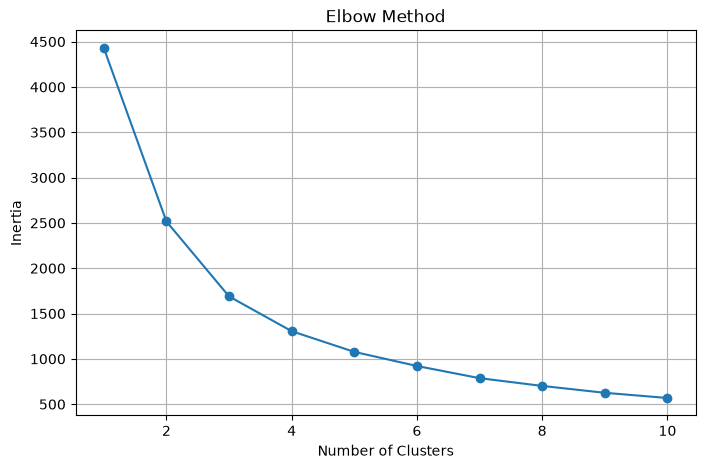

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    scores.append(score)
    print(f"K = {i}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3847
K = 3, Silhouette Score = 0.3754
K = 4, Silhouette Score = 0.3552
K = 5, Silhouette Score = 0.3394
K = 6, Silhouette Score = 0.3385
K = 7, Silhouette Score = 0.3326
K = 8, Silhouette Score = 0.3317
K = 9, Silhouette Score = 0.3389
K = 10, Silhouette Score = 0.3320


In [34]:
optimal_k = 3

print("Optimal Number of Clusters =", optimal_k)

Optimal Number of Clusters = 3


In [35]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(pca_data)

df.head()

,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Cluster
0,0,856,3,5,570.62,596,2,4,359,7,1,3,2853.10,2023,1,4,1
1,1,888,4,2,151.35,512,4,4,1074,3,1,4,302.70,2024,8,23,2
2,2,950,6,5,550.68,294,1,0,416,8,0,0,2753.40,2024,2,27,1
3,3,332,0,1,273.19,124,2,3,691,5,1,1,273.19,2023,10,15,0
4,4,951,5,4,626.01,407,4,1,245,8,1,0,2504.04,2025,5,8,1


In [38]:
df["Cluster"].value_counts()

Cluster
2    414
1    394
0    392
Name: count, dtype: int64

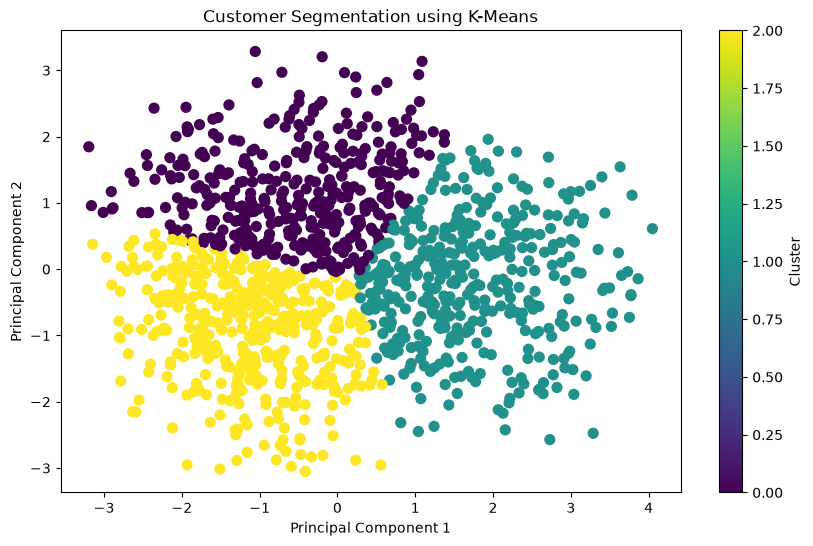

In [39]:
plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [40]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
Cluster,,,,,,,,,,,,,,,,
0,594.642857,505.035714,2.716837,2.928571,228.711122,291.451531,1.732143,1.946429,617.303571,5.528061,1.533163,1.579082,598.756658,2023.367347,8.130102,16.334184
1,616.243655,659.713198,2.954315,4.147208,489.535558,335.941624,1.921320,1.926396,604.502538,7.124365,1.434010,1.982234,1992.132563,2023.776650,5.555838,16.593909
2,588.164251,618.019324,3.330918,1.818841,350.636546,359.193237,2.376812,2.086957,577.881643,3.884058,1.483092,2.355072,592.147633,2024.137681,4.391304,15.028986


In [41]:
cluster_summary.round(2)

,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
Cluster,,,,,,,,,,,,,,,,
0,594.64,505.04,2.72,2.93,228.71,291.45,1.73,1.95,617.30,5.53,1.53,1.58,598.76,2023.37,8.13,16.33
1,616.24,659.71,2.95,4.15,489.54,335.94,1.92,1.93,604.50,7.12,1.43,1.98,1992.13,2023.78,5.56,16.59
2,588.16,618.02,3.33,1.82,350.64,359.19,2.38,2.09,577.88,3.88,1.48,2.36,592.15,2024.14,4.39,15.03


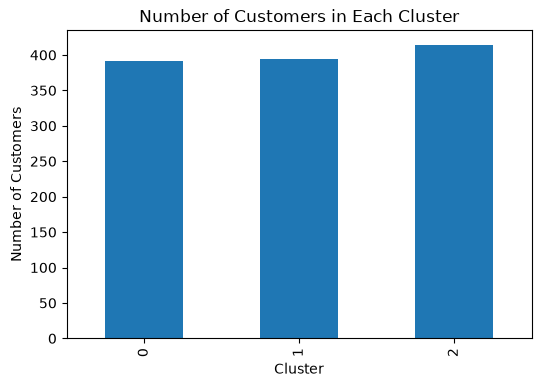

In [42]:
plt.figure(figsize=(6,4))

df["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [43]:
df.to_excel("Customer_Segmentation_Result.xlsx", index=False)

print("Customer Segmentation Project Completed Successfully!")

Customer Segmentation Project Completed Successfully!


In [44]:
cluster_summary.to_excel("Cluster_Summary.xlsx")

print("Cluster Summary Saved Successfully!")

Cluster Summary Saved Successfully!
